# Bayesian Model Mixing using Gaussian Processes: Stationary Kernel Tutorial

## Author: Alexandra C. Semposki

### Date: 23 April 2026

Welcome to the tutorial notebook for using the new `gp-bmm` method in `Taweret`! Here we will overview what the method does and how to use it on a toy model. This tutorial specifically handles the so-called "stationary" kernel, which uses the Euclidean distance between points in the input space as the main input to the kernel. In the next notebook, we will cover the scenario where this assumption is not sufficient and we need to include structure from the input space in our kernel construction. 

Below, we set up the toy model that we will be using, the so-called "SAMBA models", and then construct a stationary, squared-exponential radial basis function (RBF) kernel that will be used to mix the two models we have chosen. We will also cover the inclusion of a hyperprior on the hyperparameters of this kernel, so that we obtain better physically-motivated results, which will be extremely useful for realistic physics applications.

The core of this work was included in `Taweret` from [this paper](https://arxiv.org/abs/2505.18921) and [this paper](https://arxiv.org/abs/2505.18921), written by A. C. Semposki et al., and the accompanying package, `neutron-rich-bmm`, originally found [here](https://github.com/asemposki/neutron-rich-bmm). 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor

In [2]:
# load the proper location in Taweret for this case
import sys
sys.path.append('../../../src/Taweret')
from Taweret.models.samba_models import *
from mix.gp_bmm import *

In [3]:
# now we write out the models we need
orders=[3,4]
model_1 = Loworder(order=orders[0])
model_2 = Highorder(order=orders[1])

# make the model dict
models = {
    "1": model_1,
    "2": model_2
}

print(models, type(models))

{'1': <Taweret.models.samba_models.Loworder object at 0x12241e6d0>, '2': <Taweret.models.samba_models.Highorder object at 0x12241e5d0>} <class 'dict'>


In [4]:
#predict functions for the plot
g = np.linspace(1e-6, 1.0, 100)
predict = []

for i in models.keys():
    predict.append(models[i].evaluate(g))

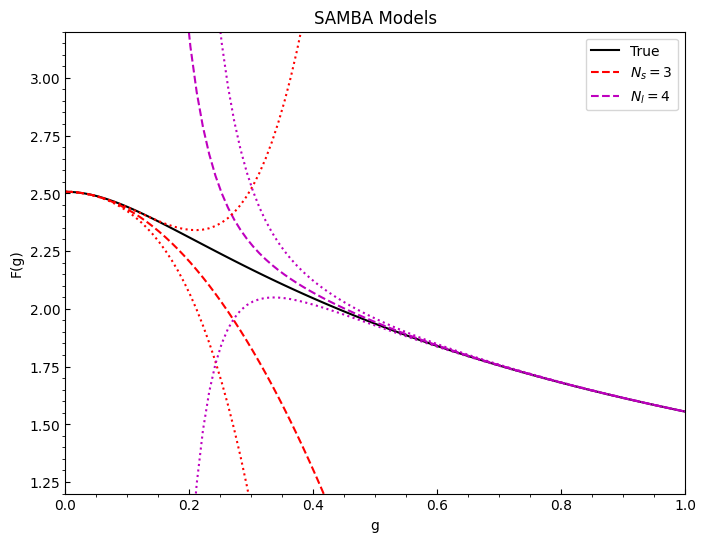

In [5]:
#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

ax.legend()

In [6]:
def build_cov_from_errors(x, sigma, ell=10.0, nugget=1e-6):
    x = np.asarray(x)
    sigma = np.asarray(sigma)

    dx = x[:, None] - x[None, :]
    rho = np.exp(-0.5 * (dx / ell)**2)

    C = np.outer(sigma, sigma) * rho
    C += nugget * np.eye(len(x))
    return C

# take some training data from these, and make some covariances up for the toy case
x1 = g[:30:5]
x2 = np.append(g[40:-1:5], g[-1])

# cut the data as well
data1 = predict[0][0][:30:5]
sigma1 = predict[0][1][:30:5]
data2 = np.append(predict[1][0][40:-1:5], predict[1][0][-1])
sigma2 = np.append(predict[1][1][40:-1:5], predict[1][1][-1])

# try the covariance function here
cov1 = build_cov_from_errors(x1, sigma1, ell=0.1, nugget=1e-6)
cov2 = build_cov_from_errors(x2, sigma2, ell=1.0, nugget=1e-6)

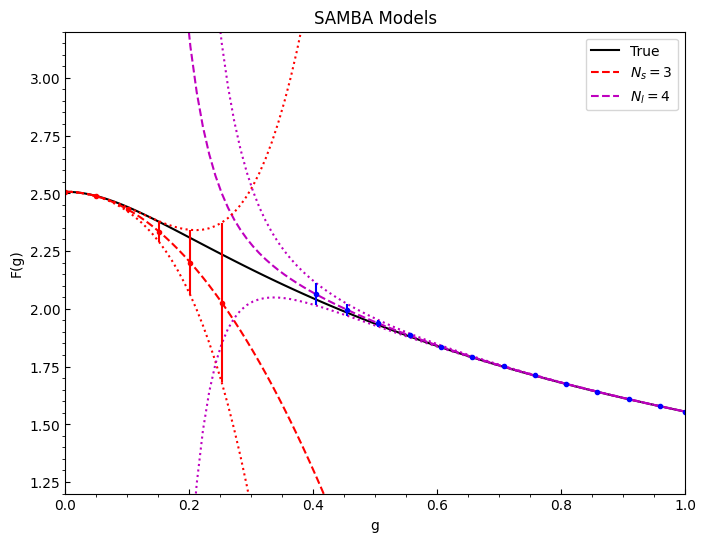

In [7]:
#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

ax.legend()
plt.show()

In [8]:
# concatenate the training data
from scipy.linalg import block_diag
x_train = np.concatenate((x1, x2)).reshape(-1,1)
y_train = np.concatenate((data1,data2)).reshape(-1,1)

# covariance matrix
alpha = block_diag(cov1, cov2)

Now we have our training data, so let's try to construct a valid *stationary* GP for this problem that is able to capture the underlying truth. We begin by choosing the default priors that the mixing class already contains.

In [9]:
# now we make a kernel to send to the class
kernel = C(constant_value=1.1, constant_value_bounds=[0.25,2.25]) * RBF(length_scale=0.05, length_scale_bounds=[0.02,0.1])

In [10]:
# load the class for mixing with basic prior assumptions
bmm = GPmixing(g, models=models, alpha=alpha, kernel=kernel, priors=True, prior_params=None, prior_choice='rbfnorm')

In [11]:
# try looking at the unconstrained prior
prior = bmm.prior_predict()  # weird, just zero? should get some nonzero value for something...

In [15]:
evalprior = bmm.evaluate(x_train)

1.05**2 * RBF(length_scale=0.05)


In [16]:
# train the GP using the train function
bmm.train(x_train, y_train)

In [17]:
print('Initial kernel:', bmm.gpr.kernel)
print('Trained kernel:', bmm.gpr.kernel_)

Initial kernel: 1.05**2 * RBF(length_scale=0.05)
Trained kernel: 1**2 * RBF(length_scale=0.0994)


In [18]:
# let's predict with this kernel now
predictions = bmm.predict()

# check the keys of the dict
print(predictions.keys())

dict_keys(['x', 'mean', 'std', 'cov'])


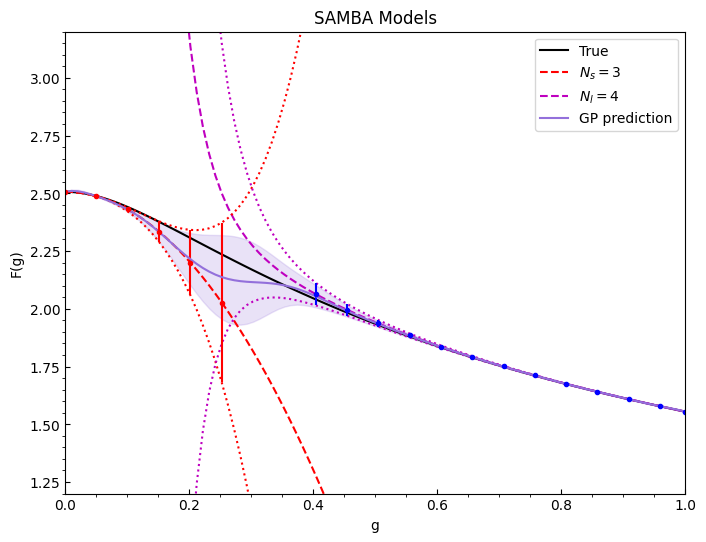

In [19]:
# plot these results over the original models and the data
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

# GP results
ax.plot(predictions['x'], predictions['mean'], color='mediumpurple', label='GP prediction')
ax.fill_between(predictions['x'], predictions['mean']-predictions['std'],
                predictions['mean']+predictions['std'], color='mediumpurple', alpha=0.2)

ax.legend()
plt.show()

This prediction is pretty good! Next we improve the priors so that we can test different kernels....

**Remaining tasks:**
- Add custom prior values here instead of just default, using prior_params
- Fluff out with text discussing what stationary is and which kernels exist

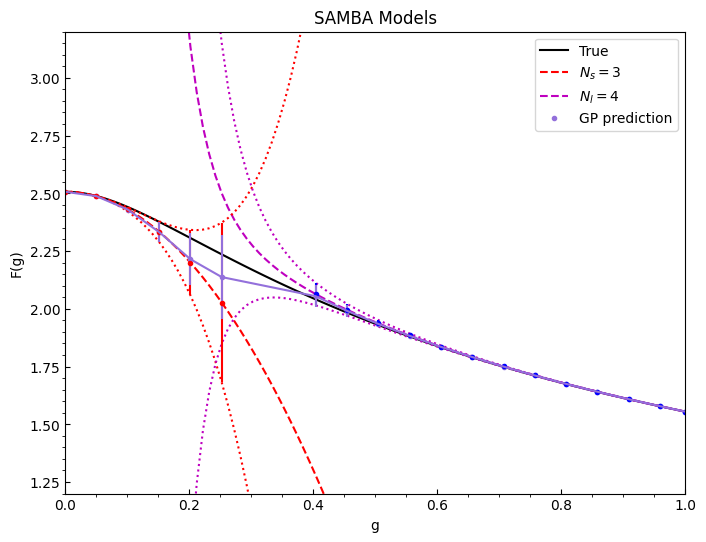

In [20]:
# evaluate function testing and plotting
evaluate = bmm.evaluate(x_train)

# plot these results over the original models and the data
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

# GP results
ax.plot(evaluate['x'], evaluate['mean'], color='mediumpurple', label='GP prediction', marker='.', linestyle=' ')
ax.errorbar(evaluate['x'], evaluate['mean'], evaluate['std'], color='mediumpurple')

ax.legend()
plt.show()

Running the `evaluate` function after the training does appear to look good!

In [32]:
print('Parameters:', bmm.map)

Parameters: [1.00605533 0.09937198]


Now we test using different prior starting points instead of the default parameters.